In [1]:
import pytometry as pk

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

_FCS_DIR = next(
    (
        _p / "fcs"
        for _p in (Path.cwd(), *Path.cwd().parents)
        if (_p / "common.py").is_file()
    ),
    Path.cwd(),
)
fcs_path = str(_FCS_DIR / "_e270_184A1_A_0_egf_singlets_egf.fcs.fcs")
sample = pk.io.read_fcs(fcs_path)

/opt/homebrew/Cellar/python@3.13/3.13.14_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
import numpy as np
import pandas as pd
import synapseclient
import matplotlib.pyplot as plt
syn = synapseclient.Synapse()
syn.login()

Welcome, Fabian Froehlich!



In [4]:
df_sc = pd.read_csv(syn.get("syn20613594").path)
df_sc_2656 = df_sc[df_sc['fileID']==2656]

[WARNING] /var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_28013/1323005014.py:1: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  df_sc = pd.read_csv(syn.get("syn20613594").path)



[syn20613594:184A1.csv]: Found existing file at /Users/frohlif/.synapseCache/703/42210703/184A1.csv, skipping download.


In [5]:
def scalar_affine_fit(A, B):
    # Fit B = scale * A + shift
    # ymax = scale * xmax + shift
    # ymin = scale * xmin + shift
    scale = (B.max() - B.min()) / (A.max() - A.min())
    shift = B.min() - scale * A.min()
    return scale, shift

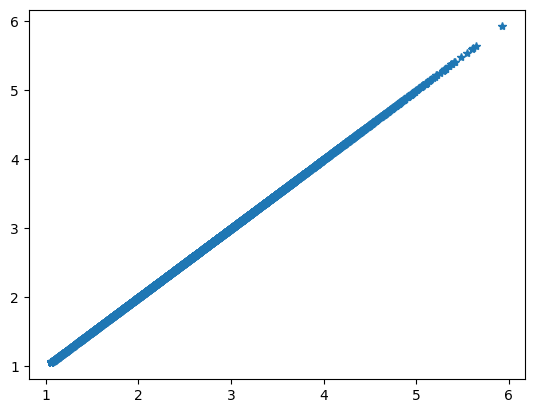

In [6]:
x_transformed = np.asinh((sample.T['163Dy_p-p90RSK'].X[0,:] + 1))
scale, shift = scalar_affine_fit(x_transformed, df_sc_2656['p.p90RSK'].values)
x_transformed = x_transformed * scale + shift
plt.plot(np.sort(df_sc_2656['p.p90RSK'].values), np.sort(x_transformed), '*')
